In [52]:
from astropy import units as u
from astropy.constants import G, c
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import spacehub_calc
from spacehub_calc import TwoBodyOrbit, mag
import matplotlib.animation as animation
from IPython.display import HTML
from orbits import distance, get_com, calc_angle
import orbits

$v_{\infty}^2 = 1.5  \frac{G m^2}{\mu a_b}$

$a_b = 10AU$

$r_{start} = 100AU$

$cos(i) = 1$

$b\in[1,40]AU$

In [53]:
m = 1 * u.Msun
a_b = 10 * u.AU
mu = m**2/(m+m)
v_inf = np.sqrt(1.5 * G * (m**2) / (a_b * mu))
v_inf.to(u.km/u.s)

<Quantity 16.31374758 km / s>

In [54]:
sample_file = "simulation_results/2+1_sample-2d.txt"
ptc_file = "simulation_results/2+1_ptcres-2demo.txt"
ordered_inputs = "simulation_results/ordered_inputs-2demo.txt"

In [55]:
indf = pd.read_csv(ordered_inputs)

In [56]:
data = orbits.load_spacehub_data(ptc_file)[1]

In [57]:
npoints = len(data["time"])
data["ecc01"] = mag(orbits.get_ecc(data, 0, 1))
data["ecc02"] = mag(orbits.get_ecc(data, 0, 2))
data["ecc12"] = mag(orbits.get_ecc(data, 1, 2))
data["rx01"], data["ry01"], data["rz01"] = distance(data, 'p', 0, 1)
data["rx02"], data["ry02"], data["rz02"] = distance(data, 'p', 0, 2)
data["rx12"], data["ry12"], data["rz12"] = distance(data, 'p', 1, 2)

In [58]:
result_df = pd.DataFrame(columns=["b", "azi", "incl", "ionized", "outcome", "rx01", "ry01", "rz01", "rx02", "ry02", "rz02", "rx12", "ry12", "rz12"])
for i in range(0, npoints):
    row = {}
    row["b"] = indf.at[i, "b"]
    row["azi"] = indf.at[i, "azi"]
    row["incl"] = indf.at[i, "incl"]
    row["ionized"] = 1 if data["ecc01"][i]  >= 1 else 0
    e_ij = np.array([data["ecc01"][i], data["ecc02"][i], data["ecc12"][i]])
    bound = np.where((e_ij > 0) & (e_ij < 1))[0]
    if len(bound) == 0:
        row["outcome"] = "Unbound"
    elif bound[0] == 0:
        row["outcome"] = "a-b"
    elif bound[0] == 1:
        row["outcome"] = "a-I"
    elif bound[0] == 2:
        row["outcome"] = "b-I"
    if len(bound) > 1:
        print(f"triple: {i}")
        row["outcome"] = "Trinary"
    #add distances in case I want to plot in cartesian
    row["rx01"], row["ry01"], row["rz01"] = data["rx01"][i], data["ry01"][i], data["rz01"][i]
    row["rx02"], row["ry02"], row["rz02"] = data["rx02"][i], data["ry02"][i], data["rz02"][i]
    row["rx12"], row["ry12"], row["rz12"] = data["rx12"][i], data["ry12"][i], data["rz12"][i]
    result_df = pd.concat([result_df, pd.DataFrame(row, index=[len(result_df)])])
        
result_df
    

triple: 3
triple: 5
triple: 21
triple: 23
triple: 27
triple: 28
triple: 55
triple: 56
triple: 68
triple: 74
triple: 75
triple: 76
triple: 77
triple: 102
triple: 106
triple: 120
triple: 126
triple: 128
triple: 155
triple: 156
triple: 174
triple: 175
triple: 176
triple: 203
triple: 204
triple: 207
triple: 219
triple: 220
triple: 223
triple: 227
triple: 228
triple: 256
triple: 269
triple: 271
triple: 273
triple: 277
triple: 320
triple: 321
triple: 324
triple: 326
triple: 345
triple: 355
triple: 369
triple: 370
triple: 371
triple: 372
triple: 373
triple: 394
triple: 403
triple: 404
triple: 425
triple: 426
triple: 427
triple: 454
triple: 455
triple: 472
triple: 474
triple: 477
triple: 504
triple: 505
triple: 507
triple: 521
triple: 523
triple: 524
triple: 525
triple: 526
triple: 527
triple: 553
triple: 554
triple: 571
triple: 572
triple: 574
triple: 576
triple: 604
triple: 606
triple: 622
triple: 671
triple: 674
triple: 705
triple: 706
triple: 722
triple: 723
triple: 724
triple: 726
triple:

,b,azi,incl,ionized,outcome,rx01,ry01,rz01,rx02,ry02,rz02,rx12,ry12,rz12
0,1.0,0.000000,0,1,a-I,457.234000,2087.22900,0,7.136000,2.35900,0,-450.098000,-2084.8700,0
1,1.0,0.063466,0,1,a-I,294.648100,1378.66900,0,-7.004900,7.61300,0,-301.653000,-1371.0560,0
2,1.0,0.126933,0,1,b-I,-237.433700,166.21850,0,-226.038900,162.56360,0,11.394800,-3.6549,0
3,1.0,0.190400,0,0,Trinary,-31.434800,-916.80100,0,-15.750182,-931.51700,0,15.684618,-14.7160,0
4,1.0,0.253866,0,1,a-I,1659.583000,-1006.00400,0,-11.879000,-4.88200,0,-1671.462000,1001.1220,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,40.0,6.029320,0,0,Trinary,-110.573900,-547.64800,0,16.267100,-4.19600,0,126.841000,543.4520,0
9996,40.0,6.092790,0,0,Trinary,22.307719,-27.08122,0,-21.924281,35.67948,0,-44.232000,62.7607,0
9997,40.0,6.156250,0,0,a-b,8.518000,-15.76600,0,-388.642000,-438.10300,0,-397.160000,-422.3370,0
9998,40.0,6.219720,0,1,b-I,-437.413000,1139.26400,0,-435.794000,1126.60300,0,1.619000,-12.6610,0


Text(0.5, 1.0, '$\\bar{R}_0^i(t=6t_{\\nu})$')

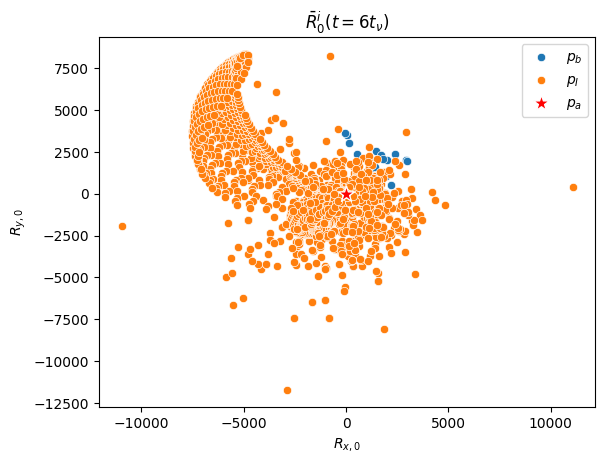

In [59]:
unionized = result_df[(result_df["ionized"]==0) & (result_df["outcome"] != "123")] #Ignore the 4 cases where all 3 particles remained bound
fig, ax = plt.subplots()
sns.scatterplot(unionized, x="rx01", y="ry01", ax=ax, label=r"$p_b$")
sns.scatterplot(unionized, x="rx02", y="ry02", ax=ax, label=r"$p_I$")
sns.scatterplot(x=[0], y=[0], ax=ax, label=r"$p_a$", marker='*', s=150, c='red')
ax.legend()
ax.set_xlabel(r"$R_{x,0}$")
ax.set_ylabel(r"$R_{y,0}$")
ax.set_title(r"$\bar{R}_0^i(t=6t_{\nu})$")


Text(5.069444444444445, 0.5, '$f_{ionized}$')

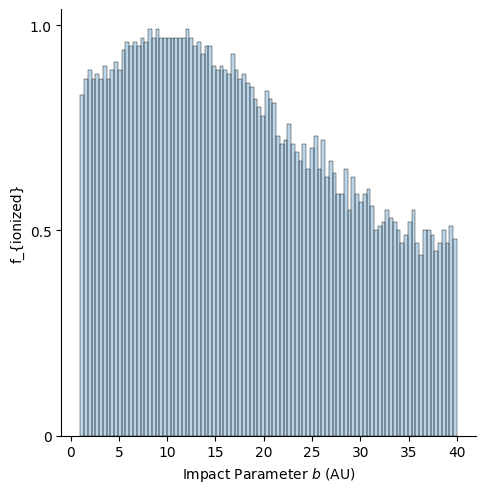

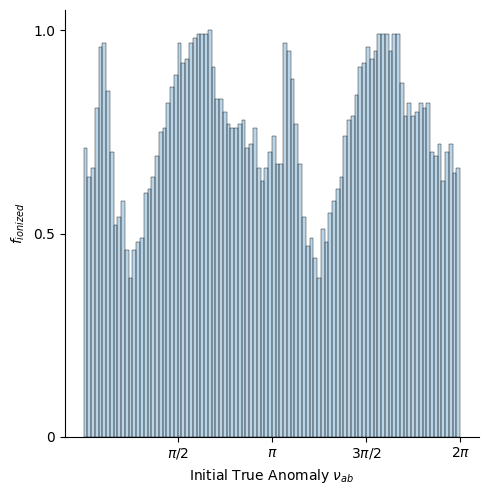

In [60]:
#ab = 10AU
ionized_mask = result_df["ionized"] == 1
b_len = len(result_df)/result_df["b"].nunique()
g = sns.displot(result_df[ionized_mask], x="b", bins=result_df["b"].nunique(), alpha=0.3)
g.ax.set_yticks([0, (b_len/2), b_len])
g.ax.set_ylabel(r"f_{ionized}")
g.ax.set_xlabel(r"Impact Parameter $b$ (AU)")
g.ax.set_yticklabels([0, 0.5, 1.0])

azi_len = len(result_df)/result_df["azi"].nunique()
g = sns.displot(result_df[ionized_mask], x="azi", bins=result_df["b"].nunique(), alpha=0.3)
g.ax.set_yticks([0, (b_len/2), b_len])
g.ax.set_yticklabels([0, 0.5, 1.0])
g.ax.set_xticks([np.pi/2, np.pi, 1.5*np.pi, 2*np.pi])
g.ax.set_xticklabels([ r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
g.ax.set_xlabel(r"Initial True Anomaly $\nu_{ab}$")
g.ax.set_ylabel(r"$f_{ionized}$")


In [61]:
sigma_ion = 2*np.pi * (max(result_df[ionized_mask]["b"]) * u.AU)**2
sigma_ion.si

<Quantity 2.24983503e+26 m2>

<Axes: xlabel='azi', ylabel='b'>

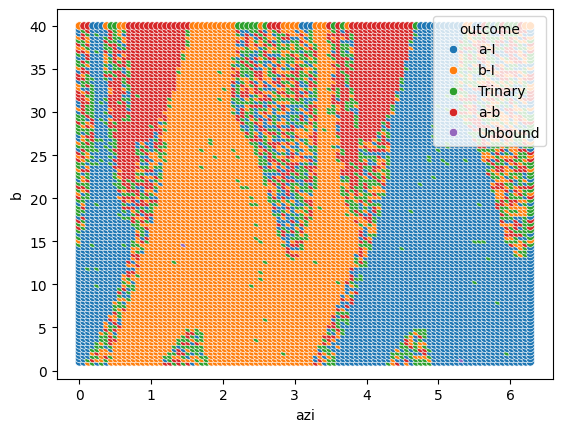

In [62]:
sns.scatterplot(result_df, x='azi', y='b', hue='outcome')